<a href="https://colab.research.google.com/github/nesishaji/DL-ML-Projects/blob/main/Student_Performance/FinalProject2_StudentPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Tile: AI based Student Performance Prediction System.

Problem statement: Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance and using historical academic and behavioural data to support timely intervention.

Objective: To build a machine learning model that perdicts whether a student will perform well or poorly based on multiple factors and provide insights for imporvement.

Dataset: Student academic dataset containing

1. Attendance Percentage
2. Internal assessment marks
3. Previous semester grades
4. Study hours
5. Participation in activities
6. Socio economic indicators

You can use public dataset or create a realistic one.


Technologies used

1. Python
2. Pandas
3. NumPy
4. Matplotlib and Seaborn
5. Scikit learn
6. Jupyter Notebook

Workflow

1. Data understanding and problem definition
2. Data Cleaning and handling missing values
3. Exploratory data analysis
4. Feature selection and encoding
5. Train test split
6. Model building using Logistic Regression Random Forest
7. Model evaluation using accuracy precision recall and confusion matrix
8. Result interpretation and insights
9. Conclusion and future scope.

Output

Prediction of student performance category

Important features influencing performance

Visual dashboards showing trends.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the Students dataset

df=pd.read_csv('/content/student_performance_100k.csv')
df.head()

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Sem_Grade,Study_Hours_Per_Week,Activity_Participation,Socio_Economic_Status,Performance
0,78,87,B,7,Yes,Low,0
1,91,41,A,18,Yes,Low,0
2,68,42,C,4,No,Medium,0
3,54,41,C,4,No,High,0
4,82,67,B,1,No,High,0


In [ ]:
df.tail()

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Sem_Grade,Study_Hours_Per_Week,Activity_Participation,Socio_Economic_Status,Performance
99995,94,50,A,15,No,Medium,0
99996,46,32,B,14,Yes,Medium,0
99997,91,52,E,9,Yes,Medium,0
99998,82,53,A,17,No,Low,0
99999,81,82,A,7,Yes,High,0


## **2 .Understand the Data Types and Summary**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Attendance_Percentage      100000 non-null  int64 
 1   Internal_Assessment_Marks  100000 non-null  int64 
 2   Previous_Sem_Grade         100000 non-null  object
 3   Study_Hours_Per_Week       100000 non-null  int64 
 4   Activity_Participation     100000 non-null  object
 5   Socio_Economic_Status      100000 non-null  object
 6   Performance                100000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 5.3+ MB


In [ ]:
df.shape

(100000, 7)

## **3. Data cleaning**

**1. Checking null values**

In [ ]:
df.isnull().sum()

,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Previous_Sem_Grade,0
Study_Hours_Per_Week,0
Activity_Participation,0
Socio_Economic_Status,0
Performance,0


we can use **unique()** to find **distinct** values in a object data column and **value_counts()** to see the **frequency of each unique value**.

In [ ]:
print (df['Activity_Participation'].unique())

['Yes' 'No']


In [ ]:
print(df['Socio_Economic_Status'].unique())

['Low' 'Medium' 'High']


In [ ]:
print(df['Performance'].unique())

[0 1]


In [ ]:
print(df['Previous_Sem_Grade'].unique())

['B' 'A' 'C' 'E' 'D' 'F']


### ** Convert all object data to numerical**

In [ ]:
# replacing "Socio_Economic_Status" and 'Student_Performance'because its ordinal data so replacing is better accurate
df["Socio_Economic_Status"].replace(['Low','Medium',"High"],[1,2,3],inplace=True)
df['Previous_Sem_Grade'].replace(['A','B','C','D','E','F'],[6,5,4,3,2,1],inplace=True)

df


/tmp/ipykernel_3226/2940873778.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Socio_Economic_Status"].replace(['Low','Medium',"High"],[1,2,3],inplace=True)
/tmp/ipykernel_3226/2940873778.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Socio_Economic_Status"].replace(['Low','Medium',

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Sem_Grade,Study_Hours_Per_Week,Activity_Participation,Socio_Economic_Status,Performance
0,78,87,5,7,Yes,1,0
1,91,41,6,18,Yes,1,0
2,68,42,4,4,No,2,0
3,54,41,4,4,No,3,0
4,82,67,5,1,No,3,0
...,...,...,...,...,...,...,...
99995,94,50,6,15,No,2,0
99996,46,32,5,14,Yes,2,0
99997,91,52,2,9,Yes,2,0
99998,82,53,6,17,No,1,0


Converting  the nominal data, 'Activities_Participation', to numerical values using labelencoder class

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Activity_Participation']=le.fit_transform(df['Activity_Participation'])

In [ ]:
df

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Sem_Grade,Study_Hours_Per_Week,Activity_Participation,Socio_Economic_Status,Performance
0,78,87,5,7,1,1,0
1,91,41,6,18,1,1,0
2,68,42,4,4,0,2,0
3,54,41,4,4,0,3,0
4,82,67,5,1,0,3,0
...,...,...,...,...,...,...,...
99995,94,50,6,15,0,2,0
99996,46,32,5,14,1,2,0
99997,91,52,2,9,1,2,0
99998,82,53,6,17,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Attendance_Percentage      100000 non-null  int64
 1   Internal_Assessment_Marks  100000 non-null  int64
 2   Previous_Sem_Grade         100000 non-null  int64
 3   Study_Hours_Per_Week       100000 non-null  int64
 4   Activity_Participation     100000 non-null  int64
 5   Socio_Economic_Status      100000 non-null  int64
 6   Performance                100000 non-null  int64
dtypes: int64(7)
memory usage: 5.3 MB


## **Visualization**

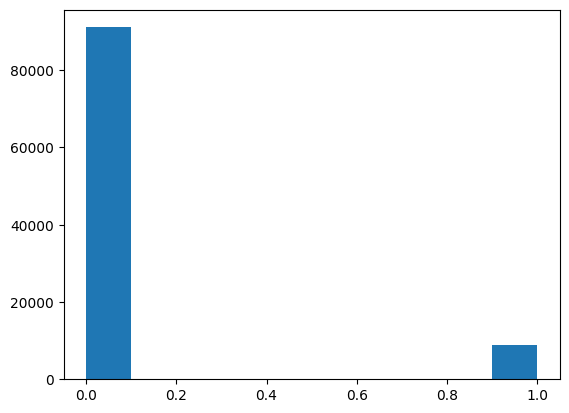

In [ ]:
plt.hist(df["Performance"])
plt.show()

<Axes: >

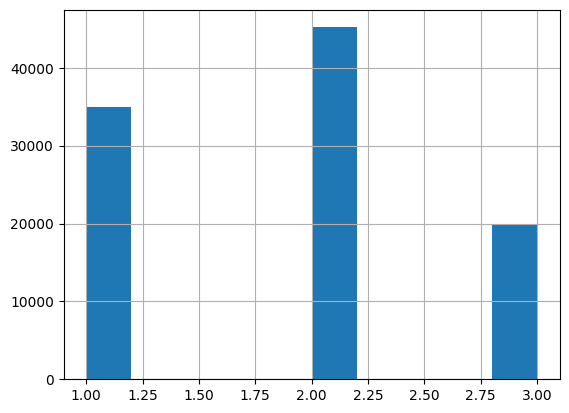

In [ ]:
# check Socio_Economic_Status distribution

df["Socio_Economic_Status"].hist()

<Axes: >

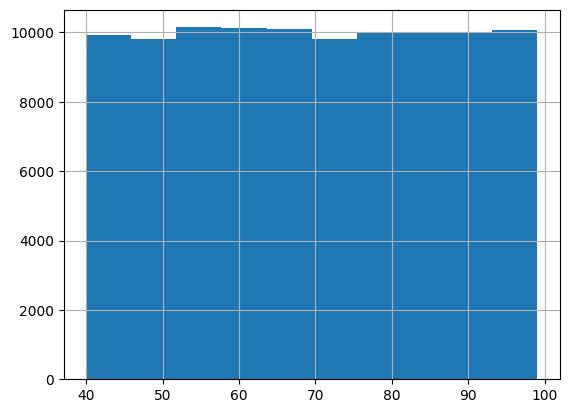

In [ ]:
df["Attendance_Percentage"].hist()

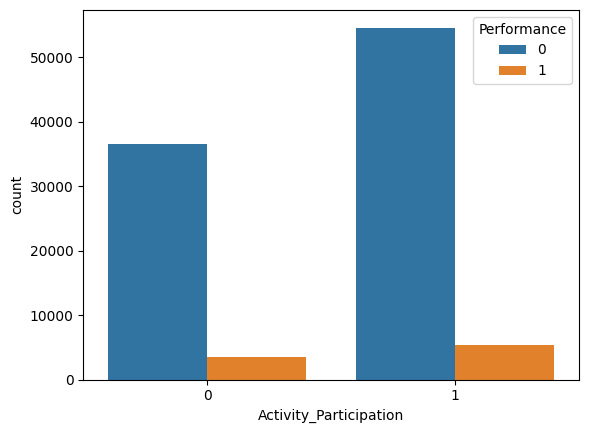

In [ ]:
sns.countplot(data=df, x='Activity_Participation', hue='Performance')
plt.show()

### After conversion check correlation

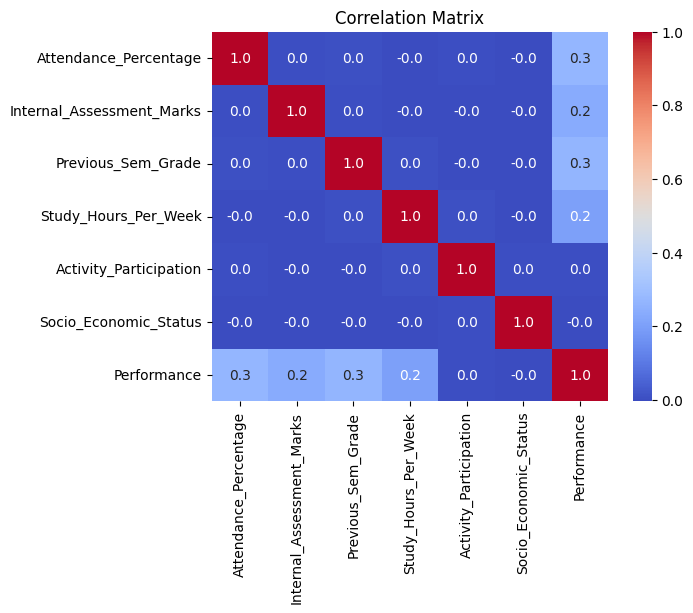

In [ ]:
# Correlation matrix
corr_matrix = df.corr()

# Heatmap of correlation matrix
sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm') # 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

### check : -Collinearity  ,multicollinearity

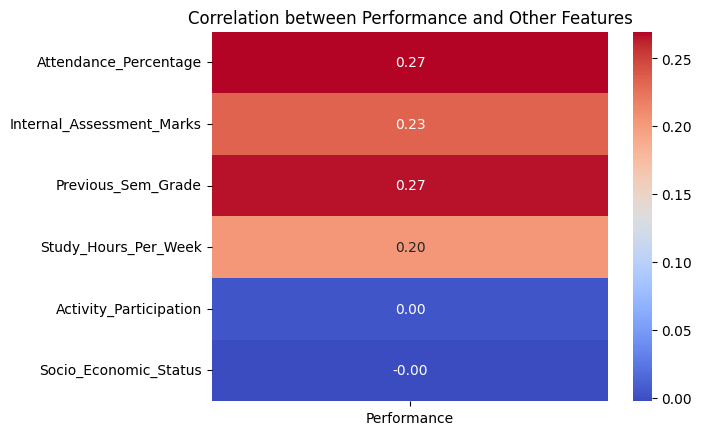

In [ ]:
# Calculate the correlation between 'Performance' and all other columns
Performance_corr = df.corr()['Performance']
# Remove the correlation of 'Performance'with itself (which is always 1)
Performance_corr = Performance_corr.drop('Performance')
# Create a heatmap to visualize the correlations
sns.heatmap(Performance_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})  # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between Performance and Other Features')
plt.show()


###  **Now remove less correlated**

In [ ]:
df.drop(["Activity_Participation","Socio_Economic_Status"],axis=1,inplace=True)

In [ ]:
df.shape

(100000, 5)

# After **EDA** we can predict

## Use LogisticRegression model if our dataset is classification (means discrete)  & if our dataset is regression (means continuous) use LinearRegression

## 1. LogisticRegression

In [ ]:
# use logisticRegression because our dataset is classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas

X = df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]  # Features
y = df['Performance']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state


# Train a baseline logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.94


## 2. KFOLD

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [ ]:
# Split features and target
X = df.drop('Performance', axis=1)
y = df['Performance']

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

# Track best fold data
best_accuracy = 0
best_fold = -1

# Save best fold's data
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred

# Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.94075
Fold 2 Accuracy: 0.9438
Fold 3 Accuracy: 0.94465
Fold 4 Accuracy: 0.9433
Fold 5 Accuracy: 0.9429

 Best Fold: 3 with Accuracy: 0.94465


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.94465

## 3. Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas


X = df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]  # Features
y = df['Performance']  # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state



# Train DecisionTree Classifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


## 4. Support Vector Machine(SVM)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import pandas as pd

In [ ]:
X=df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]
y = df['Performance']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',LinearSVC())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f'Linear SVC Pipeline accuracy: {accuracy:.2f}')

Linear SVC Pipeline accuracy: 0.94


## 5. Random Forest Classifier

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

Using Random Forest Classifier

In [ ]:
X=df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]
y = df['Performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict and evaluate the model

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


##**6. XG Boost**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
# Features and target
X=df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]
y = df['Performance']

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


## 7. Ada Boost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

Define features and target

In [ ]:
# Features and target
X=df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]
y = df['Performance']

Train AdaBoost model

In [ ]:
model = AdaBoostClassifier()

model.fit(X_train, y_train)

AdaBoostClassifier()

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


##  8. Deep Learning

##Artificial Neural Networks (ANN)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Features and target
X=df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade',"Study_Hours_Per_Week"]]
y = df['Performance']

In [ ]:
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(4,), activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))               # Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9492 - loss: 0.1277
Epoch 2/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9715 - loss: 0.0754
Epoch 3/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9769 - loss: 0.0596
Epoch 4/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9800 - loss: 0.0510
Epoch 5/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9828 - loss: 0.0451
Epoch 6/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9829 - loss: 0.0433
Epoch 7/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9839 - loss: 0.0394
Epoch 8/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9853 - loss: 0.0362
Epoch 9/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9866 - loss: 0.0332
Epoch 10/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9868 - loss: 0.0329


In [ ]:

# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - accuracy: 0.9940 - loss: 0.0191
Model Accuracy: 99.40%


# Conclusion

This project analyzed student performance prediction using multiple machine learning and deep learning techniques, including Logistic Regression, K-Fold Cross Validation, Decision Tree Algorithm, and Artificial Neural Networks (ANN). The objective was to compare the performance of different models and identify the most accurate method for predicting student outcomes.
After training and evaluating all models, the results showed that the Deep Learning ANN model achieved the highest accuracy among all the techniques used.
Overall, this project highlights the importance of machine learning and deep learning techniques in predicting student performance. The findings can help educational institutions identify students who may need additional support and enable better academic planning and decision-making.